# Chapter 3b: Supervised Fine-Tuning (turning the base into a chat model)

In 3a we pretrained `data/base.pt` — a ~50M GPT that *continues* text. Ask it "What is the capital of France?" and it won't answer; it'll just keep generating web prose, because all it has ever seen is web prose.

**SFT (Supervised Fine-Tuning)** fixes the *behavior*, not the knowledge. We show the model a few thousand `instruction → response` examples formatted as a conversation, and it learns the **shape**: "when text looks like a question in this template, produce an answer and then stop." The facts it answers with were already learned in pretraining — SFT just unlocks the conversational interface.

> **The single most important idea in this notebook: loss masking.** We feed the model the *whole* example (prompt + response), but we only compute loss on the **response** tokens. We do **not** want to teach it to generate the user's question — only to generate good answers to questions. Everything else here is plumbing around that one idea.

### What's new vs 3a

| Concept | New idea |
|---|---|
| **Chat template** | a fixed text format that marks where the prompt ends and the response begins |
| **Loss masking** | label prompt tokens `-100` so cross-entropy ignores them; train only on the response |
| **Padding + causal attention** | variable-length examples batched together; why right-padding needs *no* extra mask here |
| **SFT hyperparameters** | low LR, 1–3 epochs — why fine-tuning is gentle (catastrophic forgetting) |
| **Chat-style generation** | format the prompt, generate, **stop at the end-of-turn token** |

Same pattern: concept → `TODO` → `# check`.

## 0. Setup — load the base model from 3a

We reuse the exact `GPT`/`Block`/`CausalSelfAttention` classes from 3a (given again so this notebook stands alone) and load `data/base.pt`. If you haven't run 3a yet, do that first — there's nothing to fine-tune otherwise.

In [1]:
import math
import os
import time

import tiktoken
import torch
import torch.nn.functional as F
from torch import nn
from dataclasses import dataclass

device = "cuda" if torch.cuda.is_available() else "cpu"
if device == "cuda":
    # same free throughput knobs as 3a (TF32 matmuls + cuDNN autotune)
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.backends.cudnn.benchmark = True
DATA_DIR = "data"
enc = tiktoken.get_encoding("gpt2")
EOT = enc.eot_token          # 50256 -- doubles as our end-of-turn marker AND padding id
VOCAB_SIZE = enc.n_vocab
print("device:", device)

device: cuda


In [2]:
# --- GPT classes, identical to 3a (given) ---
@dataclass
class Config:
    vocab_size: int = VOCAB_SIZE
    d_model: int = 512
    n_heads: int = 8
    d_ff: int = 2048
    n_layers: int = 8
    block_size: int = 256
    dropout: float = 0.0


class CausalSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.0):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads; self.d_k = d_model // n_heads
        self.qkv = nn.Linear(d_model, 3 * d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.dropout = dropout
        self.out_proj.RESIDUAL_SCALE_INIT = True

    def forward(self, x):
        q, k, v = self.qkv(x).chunk(3, dim=-1)
        b, t, _ = x.size()
        q = q.view(b, t, self.n_heads, self.d_k).transpose(1, 2)
        k = k.view(b, t, self.n_heads, self.d_k).transpose(1, 2)
        v = v.view(b, t, self.n_heads, self.d_k).transpose(1, 2)
        out = F.scaled_dot_product_attention(q, k, v, is_causal=True,
            dropout_p=self.dropout if self.training else 0.0)
        return self.out_proj(out.transpose(1, 2).reshape(b, t, -1))


class Block(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.0):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = CausalSelfAttention(d_model, n_heads, dropout)
        self.ln2 = nn.LayerNorm(d_model)
        self.mlp_fc = nn.Linear(d_model, d_ff)
        self.mlp_act = nn.GELU()
        self.mlp_proj = nn.Linear(d_ff, d_model)
        self.mlp_drop = nn.Dropout(dropout)
        self.mlp_proj.RESIDUAL_SCALE_INIT = True

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp_drop(self.mlp_proj(self.mlp_act(self.mlp_fc(self.ln2(x)))))
        return x


class GPT(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg; self.block_size = cfg.block_size; self.n_layers = cfg.n_layers
        self.wte = nn.Embedding(cfg.vocab_size, cfg.d_model)
        self.wpe = nn.Embedding(cfg.block_size, cfg.d_model)
        self.drop = nn.Dropout(cfg.dropout)
        self.blocks = nn.ModuleList([Block(cfg.d_model, cfg.n_heads, cfg.d_ff, cfg.dropout)
                                     for _ in range(cfg.n_layers)])
        self.ln_f = nn.LayerNorm(cfg.d_model)
        self.lm_head = nn.Linear(cfg.d_model, cfg.vocab_size, bias=False)
        self.lm_head.weight = self.wte.weight
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            std = 0.02
            if getattr(module, "RESIDUAL_SCALE_INIT", False):
                std /= math.sqrt(2 * self.n_layers)
            nn.init.normal_(module.weight, mean=0.0, std=std)
            if module.bias is not None: nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        b, t = idx.shape
        pos = torch.arange(t, device=idx.device)
        x = self.drop(self.wte(idx) + self.wpe(pos))
        for block in self.blocks: x = block(x)
        logits = self.lm_head(self.ln_f(x))
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1),
                                   ignore_index=-100)   # <-- this ignore_index is the engine of loss masking
        return logits, loss

In [3]:
# load the pretrained base
ckpt = torch.load(os.path.join(DATA_DIR, "base.pt"), map_location=device, weights_only=False)
cfg = ckpt["cfg"]
model = GPT(cfg).to(device)
model.load_state_dict(ckpt["model"])
print(f"loaded base: {sum(p.numel() for p in model.parameters())/1e6:.1f}M params, "
      f"pretrained for {ckpt['step']} steps")

loaded base: 51.1M params, pretrained for 29999 steps


## 1. The chat template

A chat template is just a **fixed text layout** that (a) marks the boundary between the user's prompt and the model's response, and (b) marks where the response *ends*. The model has no built-in concept of "turns" — the template *is* the convention, and the model learns it from the SFT examples.

We use the **Alpaca/Dolly** style (plain text, no new tokens needed):

```
### Instruction:
{instruction}

### Input:
{context}            <- this whole block is OMITTED when there's no context

### Response:
{response}<|endoftext|>
```

**Two design choices, both deliberate (ponytail):**
- **No new special tokens.** We could add `<|user|>` / `<|assistant|>` tokens, but that means resizing the embedding table and training fresh rows from scratch on tiny data. The `### Instruction:` / `### Response:` text markers cost zero new tokens and the BPE tokenizer already handles them. *Add real role tokens only if this plain template measurably underperforms.*
- **`<|endoftext|>` (EOT) as the end-of-turn marker.** The model already saw EOT between documents in pretraining, so "EOT = stop" transfers. At inference we generate until the model emits EOT, then cut.

**The prompt/response split** (this is what loss masking will hinge on):
- **prompt** = everything from `### Instruction:` up to and **including** `### Response:\n`
- **response** = the answer text, followed by EOT

| variable | meaning |
|---|---|
| `ex` | one dataset row: `{instruction, context, response, ...}` |
| `prompt_str` | the template up to and including `### Response:\n` |
| `response_str` | `ex["response"]` |

In [4]:
def format_example(ex):
    """Return (prompt_str, response_str) for one Dolly row.

    Dolly fields: ex["instruction"], ex["context"] (may be ""), ex["response"].
    Build prompt_str EXACTLY up to and including "### Response:\n" so the split is clean.
    Include the "### Input:" block ONLY when ex["context"] is non-empty.
    """
    # TODO: build and return (prompt_str, response_str)
    # prompt_str template (no context):
    #   "### Instruction:\n{instruction}\n\n### Response:\n"
    # prompt_str template (with context):
    #   "### Instruction:\n{instruction}\n\n### Input:\n{context}\n\n### Response:\n"
    # response_str = ex["response"]
    if ex["context"]:
        prompt_str = f"### Instruction:\n{ex['instruction']}\n\n### Input:\n{ex['context']}\n\n### Response:\n"
    else:
        prompt_str = f"### Instruction:\n{ex['instruction']}\n\n### Response:\n"
    response_str = ex["response"]
    return prompt_str, response_str
    

In [5]:
# check -- the prompt must END with the response marker, and context must be conditional
_no_ctx = {"instruction": "Name a primary color.", "context": "", "response": "Blue."}
_ctx    = {"instruction": "Summarize.", "context": "The sky is blue.", "response": "Sky is blue."}
p1, r1 = format_example(_no_ctx)
p2, r2 = format_example(_ctx)
assert p1.endswith("### Response:\n"), "prompt must end exactly at the response marker"
assert "### Input:" not in p1, "no-context example must not contain an Input block"
assert "### Input:" in p2 and "The sky is blue." in p2, "context example must include the Input block"
assert r1 == "Blue.", "response_str should be the raw response"
print("ok: template splits cleanly\n"); print(p2 + r2)

ok: template splits cleanly

### Instruction:
Summarize.

### Input:
The sky is blue.

### Response:
Sky is blue.


## 2. Loss masking — the core of SFT

We tokenize `prompt_str` and `response_str` **separately**, concatenate the ids, and build a parallel `labels` array that is `-100` everywhere in the prompt and the real token id everywhere in the response. Then `F.cross_entropy(..., ignore_index=-100)` simply **skips** the `-100` positions — no gradient flows from them.

**Why mask the prompt at all?** If we trained on the prompt tokens too, we'd be teaching the model to *generate questions*, diluting the only thing we want: generating answers. Masking focuses 100% of the gradient on the response.

**Worked micro-example.** Suppose after tokenizing:
```
prompt_ids   = [10, 11, 12]          # "### Response:\n" etc.  (3 tokens)
response_ids = [40, 41, EOT]         # the answer + end-of-turn (3 tokens)

ids    = [10, 11, 12, 40, 41, EOT]   # what the model reads
labels = [-100,-100,-100, 40, 41, EOT]  # -100 over the prompt, real ids over the response
```
Now apply the **next-token shift** (same convention as 3a: input is `ids[:-1]`, target is `labels[1:]`):
```
x = ids[:-1]    = [10, 11, 12, 40, 41]
y = labels[1:]  = [-100,-100, 40, 41, EOT]
```
Read `y`: at the position where the model has just consumed token `12` (the last prompt token), the target is `40` — the first response token. Every position whose target is a prompt token is `-100` and contributes nothing. The model is trained *only* to predict `40, 41, EOT` — exactly the response.

| variable | shape | meaning |
|---|---|---|
| `prompt_ids` / `response_ids` | (P,) / (R,) | tokenized halves |
| `ids` | (P+R,) | full sequence the model reads |
| `labels` | (P+R,) | `-100`×P then `response_ids`; the masked targets |

**Particularity — truncation.** If `P+R` exceeds `block_size`, truncate from the **left of the prompt** (keep the response intact — it's what we train on). We keep it simple: drop examples that don't fit after a hard cap. *ponytail: dropping the rare too-long example is one line; sliding-window truncation is a feature you add only if you're losing meaningful data.*

In [6]:
def encode_example(ex, block_size):
    """Return (ids, labels) python lists, or None if it doesn't fit in block_size.

    Steps:
      1. prompt_str, response_str = format_example(ex)
      2. prompt_ids   = enc.encode_ordinary(prompt_str)
         response_ids = enc.encode_ordinary(response_str) + [EOT]   # append end-of-turn
      3. ids    = prompt_ids + response_ids
      4. labels = [-100]*len(prompt_ids) + response_ids             # mask the prompt
      5. if len(ids) > block_size: return None                      # drop (see markdown)
      6. return ids, labels
    """

    prompt_str, response_str = format_example(ex)
    prompt_ids   = enc.encode_ordinary(prompt_str)
    response_ids = enc.encode_ordinary(response_str) + [EOT]   # append
    ids   = prompt_ids + response_ids
    labels = [-100]*len(prompt_ids) + response_ids             # mask the prompt
    if len(ids) > block_size:
        return None
    return ids, labels

In [7]:
# check -- the mask must cover exactly the prompt, and labels must align with ids
_ids, _labels = encode_example(
    {"instruction": "Name a primary color.", "context": "", "response": "Blue."}, block_size=256)
assert len(_ids) == len(_labels), "ids and labels must be the same length"
# every masked position is -100; every unmasked label equals the id at that position
for i, (a, b) in enumerate(zip(_ids, _labels)):
    assert b == -100 or b == a, f"unmasked label at {i} must equal the token id"
n_train = sum(1 for b in _labels if b != -100)
assert _labels[-1] == EOT, "last label must be the EOT end-of-turn token (it's part of the response)"
assert _labels[0] == -100, "first label (deep in the prompt) must be masked"
print(f"ok: {len(_ids)} tokens, {n_train} of them trainable (the response + EOT)")

ok: 18 tokens, 3 of them trainable (the response + EOT)


## 3. Data pipeline — load Dolly-15k, batch with padding

[databricks-dolly-15k](https://huggingface.co/datasets/databricks/databricks-dolly-15k): 15k human-written instruction/response pairs. Small enough to fine-tune in minutes and to *overfit-check*. (Swap in `HuggingFaceTB/smol-smoltalk` later for the real run — see the final cell.)

**Padding — and why right-padding needs no extra attention mask here.** Examples have different lengths, but a batch tensor is rectangular, so we pad short ones up to the batch's longest. Two rules:
- pad **`ids`** with `EOT` (any id works — it'll be masked out of the loss),
- pad **`labels`** with `-100` (so the pad positions contribute zero loss).

> **The particularity people get wrong:** with a **causal** mask and **right**-padding, a real token at position *i* only attends to positions ≤ *i* — and all the pad tokens sit *after* the real content. So **no real token ever attends to a pad token**, and the pad positions' own outputs are thrown away (`-100`). That's why we need **no separate padding mask** on top of `is_causal=True`. (This breaks if you *left*-pad — then real tokens would attend to leading pads. So: right-pad only.)

| collate output | shape | meaning |
|---|---|---|
| `x` | (B, L-1) | inputs = padded ids, last col dropped (next-token shift) |
| `y` | (B, L-1) | targets = padded labels, first col dropped |

`L` = longest example in the batch (dynamic padding — cheaper than always padding to `block_size`).

In [8]:
from datasets import load_dataset
from torch.utils.data import DataLoader

raw = load_dataset("databricks/databricks-dolly-15k", split="train")
print(raw)

# pre-encode once (15k examples is small); drop the ones that don't fit
encoded = []
for ex in raw:
    out = encode_example(ex, cfg.block_size)
    if out is not None:
        encoded.append(out)
print(f"kept {len(encoded)}/{len(raw)} examples after length filter")

README.md:   0%|          | 0.00/8.20k [00:00<?, ?B/s]

databricks-dolly-15k.jsonl:   0%|          | 0.00/13.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/15011 [00:00<?, ? examples/s]

Dataset({
    features: ['instruction', 'context', 'response', 'category'],
    num_rows: 15011
})
kept 11964/15011 examples after length filter


In [9]:
def collate(batch):
    """batch: list of (ids, labels). Right-pad to the batch max, apply the next-token shift.

    Steps:
      1. L = max(len(ids) for ids, _ in batch)
      2. for each (ids, labels): pad ids up to L with EOT; pad labels up to L with -100
      3. stack into int64 tensors ids_pad (B,L), lab_pad (B,L)
      4. x = ids_pad[:, :-1]; y = lab_pad[:, 1:]      # the shift
      5. return x, y   (move to device in the training loop)
    """

    L = max(len(ids) for ids, _ in batch)
    ids_pad = torch.full((len(batch), L), EOT, dtype=torch.long)
    lab_pad = torch.full((len(batch), L), -100, dtype=torch.long)
    for i, (ids, labels) in enumerate(batch):
        ids_pad[i, :len(ids)] = torch.tensor(ids, dtype=torch.long)
        lab_pad[i, :len(labels)] = torch.tensor(labels, dtype=torch.long)
    x = ids_pad[:, :-1]; y = lab_pad[:, 1:]      # the shift
    return x, y   # move to device in the training loop


In [10]:
# check -- padding, shift, and the "no loss on pads" property
_b = [(([1,2,3,4,5]), ([-100,-100,4,5,EOT])),      # len 5
      (([1,2,3]),     ([-100,2,3]))]                # len 3 -> must be padded up to 5
_x, _y = collate(_b)
assert _x.shape == (2, 4) and _y.shape == (2, 4), "shapes wrong (should be (B, L-1))"
# the short example's padded target positions must be -100 (ignored)
assert (_y[1] == -100).sum() >= 2, "pad positions in labels must be -100"
assert _x.dtype == torch.int64, "ids must be int64 for embedding lookup"
print("ok: dynamic right-padding + shift correct\n", "x=", _x.tolist(), "\n y=", _y.tolist())

ok: dynamic right-padding + shift correct
 x= [[1, 2, 3, 4], [1, 2, 3, 50256]] 
 y= [[-100, 4, 5, 50256], [2, 3, -100, -100]]


## 4. SFT training loop

Fine-tuning is **gentle** compared to pretraining, and the reasons are concept, not trivia:

- **Low LR (≈1e-5 to 5e-5, ~10× below pretraining).** The base already knows language. A big LR would overwrite that knowledge faster than it learns the chat format — **catastrophic forgetting**. Small steps nudge behavior without erasing knowledge.
- **Few epochs (1–3).** 15k examples is tiny; more than a few passes and it starts memorizing exact responses (overfitting) instead of learning the general "answer the question" behavior.
- **Same AMP (bf16) and grad clipping** as 3a — those are about hardware/stability, not about pretrain-vs-finetune, so they carry over unchanged.

| variable | meaning |
|---|---|
| `epochs` | full passes over the SFT set (keep small) |
| `lr` | the gentle fine-tuning rate |
| `loader` | DataLoader yielding `(x, y)` batches via `collate` |

In [11]:
from tqdm.auto import tqdm

# Re-asked every `sample_interval` steps so you can watch the model go from "continues web
# text" to "answers in-template and stops" as SFT proceeds.
SAMPLE_QS = ["What is the capital of France?", "Give me one tip for sleeping better."]


def sft_train(model, loader, epochs=2, lr=3e-5, grad_clip=1.0,
              log_interval=100, sample_interval=300, sample_qs=SAMPLE_QS):
    """Fine-tune `model` on the instruction data. Returns a history dict:
       {"step", "loss", "grad_norm", "batch_time", "vram_gb"}  (x-axis = global step).
    Same instrumentation as 3a's train(): a tqdm bar with live loss / grad-norm /
    ms-per-step / VRAM + ETA, periodic logging, and chat() samples printed every
    `sample_interval` steps (the SFT analog of "samples at validation").
    """
    opt = torch.optim.AdamW(model.parameters(), lr=lr, betas=(0.9, 0.95), weight_decay=0.0)
    history = {"step": [], "loss": [], "grad_norm": [], "batch_time": [], "vram_gb": []}
    model.train()
    if device == "cuda":
        torch.cuda.reset_peak_memory_stats()
    total = epochs * len(loader)
    pbar = tqdm(total=total, desc="sft", dynamic_ncols=True)
    gstep = 0
    for epoch in range(epochs):
        for x, y in loader:
            t_step = time.time()
            x, y = x.to(device), y.to(device)

            # core SFT step (identical wiring to 3a; y already has -100 on prompt+pad)
            opt.zero_grad(set_to_none=True)
            with torch.autocast(device_type=device, dtype=torch.bfloat16):
                logits, loss = model(x, y)
            loss.backward()
            grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            opt.step()

            if device == "cuda":
                torch.cuda.synchronize()
            dt = time.time() - t_step
            vram = torch.cuda.max_memory_allocated() / 1e9 if device == "cuda" else 0.0

            history["step"].append(gstep)
            history["loss"].append(loss.item())
            history["grad_norm"].append(grad_norm.item())
            history["batch_time"].append(dt)
            history["vram_gb"].append(vram)

            avg_dt = sum(history["batch_time"][-50:]) / len(history["batch_time"][-50:])
            pbar.update(1)
            pbar.set_postfix(ep=epoch, loss=f"{loss.item():.3f}", gnorm=f"{grad_norm.item():.2f}",
                             ms=f"{avg_dt*1e3:.0f}", vram=f"{vram:.1f}G")

            if gstep % log_interval == 0:
                tqdm.write(f"epoch {epoch} step {gstep:5d} | loss {loss.item():.3f} "
                           f"| gnorm {grad_norm.item():.2f} | {avg_dt*1e3:.0f} ms/step | vram {vram:.2f} GB")
            if sample_interval and gstep > 0 and gstep % sample_interval == 0:
                for q in sample_qs:
                    tqdm.write(f"   [{gstep}] Q: {q}\n        A: {chat(model, q, max_new_tokens=40).strip()!r}")
            gstep += 1

    pbar.close()
    avg_dt = sum(history["batch_time"]) / len(history["batch_time"])
    print(f"sft done: {total} steps | avg {avg_dt*1e3:.0f} ms/step "
          f"| peak vram {max(history['vram_gb']):.2f} GB")
    return history

In [12]:
# check -- overfit ONE small batch: SFT loss must collapse (loop wiring sanity, like 3a)
_mini = DataLoader(encoded[:4], batch_size=4, shuffle=False, collate_fn=collate)
_probe = GPT(cfg).to(device); _probe.load_state_dict(ckpt["model"])  # fresh copy of base
_xb, _yb = next(iter(_mini))
_xb, _yb = _xb.to(device), _yb.to(device)
_opt = torch.optim.AdamW(_probe.parameters(), lr=1e-4)
_probe.train()
for _ in range(100):
    _opt.zero_grad(set_to_none=True)
    with torch.autocast(device_type=device, dtype=torch.bfloat16):
        _, l = _probe(_xb, _yb)
    l.backward(); _opt.step()
print(f"overfit SFT loss after 100 steps: {l.item():.4f}")
assert l.item() < 0.5, "couldn't overfit one SFT batch -- masking/collate/loop wiring is off"
print("ok: SFT loop drives masked loss down")
del _probe

overfit SFT loss after 100 steps: 0.0007
ok: SFT loop drives masked loss down


## 5. Chat-style generation — format, generate, stop at EOT

Inference must mirror training: build the **same** prompt template (ending in `### Response:\n`), let the model generate, and **stop when it emits EOT** (the end-of-turn marker it learned). If you forget to stop at EOT, the model will happily start hallucinating a *new* `### Instruction:` and answer itself.

| step | what |
|---|---|
| 1 | `prompt_str, _ = format_example({instruction, context, response:""})` |
| 2 | encode → tensor, generate token by token |
| 3 | break as soon as the sampled token is `EOT` |
| 4 | decode only the **generated** part (after the prompt), strip trailing EOT |

In [13]:
@torch.no_grad()
def chat(model, instruction, context="", max_new_tokens=200, temperature=0.7, top_k=50):
    """Format the instruction with the SFT template, generate a response, stop at EOT."""
    model.eval()
    prompt_str, _ = format_example({"instruction": instruction, "context": context, "response": ""})
    idx = torch.tensor([enc.encode_ordinary(prompt_str)], device=device)
    start_len = idx.size(1)
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -model.block_size:]
        with torch.autocast(device_type=device, dtype=torch.bfloat16):
            logits, _ = model(idx_cond)
        logits = logits[:, -1, :] / temperature
        if top_k is not None:
            v, _ = torch.topk(logits, top_k)
            logits[logits < v[:, [-1]]] = float("-inf")
        probs = F.softmax(logits, dim=-1)
        next_id = torch.multinomial(probs, num_samples=1)
        if next_id.item() == EOT:          # end-of-turn -> stop
            break
        idx = torch.cat([idx, next_id], dim=1)
    model.train()
    return enc.decode(idx[0, start_len:].tolist())

In [14]:
# check -- before SFT the base barely follows the format; this just confirms chat() runs and stops
print("BASE (pre-SFT) answer to 'What is the capital of France?':")
print(repr(chat(model, "What is the capital of France?", max_new_tokens=40)))
# no assertion on quality here -- the point of the next cell is to FIX this

BASE (pre-SFT) answer to 'What is the capital of France?':
'Why is France so important to France?\nThe capital of France is the capital of the French Republic of France and the capital of France. It is the capital of France and is also the capital of'


## 6. The real SFT run

Fine-tune the loaded base on all of Dolly, then talk to it. Given scaffolding (orchestration + plotting).

> **Expectations:** SFT loss starts around the base's level and drops fast (the format is easy to learn). After 2 epochs the model should *answer in the template and stop* — short, often correct-ish answers. It won't be ChatGPT (50M params, 15k examples), but the **behavior change** from "continues web text" to "answers and stops" is the thing you're verifying.

> **ponytail: this cell is given (run + save + plot). The learning was Phases 1–5.**

In [15]:
BATCH_SIZE = 16              # SFT sequences are short-ish; tune to your 8GB
EPOCHS = 2
LR = 3e-5

loader = DataLoader(encoded, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate)
hist = sft_train(model, loader, epochs=EPOCHS, lr=LR,
                 log_interval=100, sample_interval=300)   # generate chat samples every 300 steps

torch.save({"model": model.state_dict(), "cfg": cfg}, os.path.join(DATA_DIR, "chat.pt"))
print("saved data/chat.pt")

sft:   0%|          | 0/1496 [00:00<?, ?it/s]

epoch 0 step     0 | loss 3.743 | gnorm 5.47 | 197 ms/step | vram 4.73 GB
epoch 0 step   100 | loss 4.226 | gnorm 6.47 | 112 ms/step | vram 5.32 GB
epoch 0 step   200 | loss 3.844 | gnorm 4.74 | 110 ms/step | vram 5.32 GB
epoch 0 step   300 | loss 4.130 | gnorm 6.05 | 118 ms/step | vram 5.32 GB
   [300] Q: What is the capital of France?
        A: 'The capital of France is France.'
   [300] Q: Give me one tip for sleeping better.
        A: 'If I were a kid, I would make a little sleeping better. I would get a little bit more sleep. \n\nCoffee is good for sleep. \n\nThe most important'
epoch 0 step   400 | loss 3.388 | gnorm 5.09 | 132 ms/step | vram 5.32 GB
epoch 0 step   500 | loss 3.783 | gnorm 6.28 | 96 ms/step | vram 5.32 GB
epoch 0 step   600 | loss 4.102 | gnorm 5.16 | 129 ms/step | vram 5.32 GB
   [600] Q: What is the capital of France?
        A: 'The capital of France is France.'
   [600] Q: Give me one tip for sleeping better.
        A: 'Gandhi is an ideal time for people t

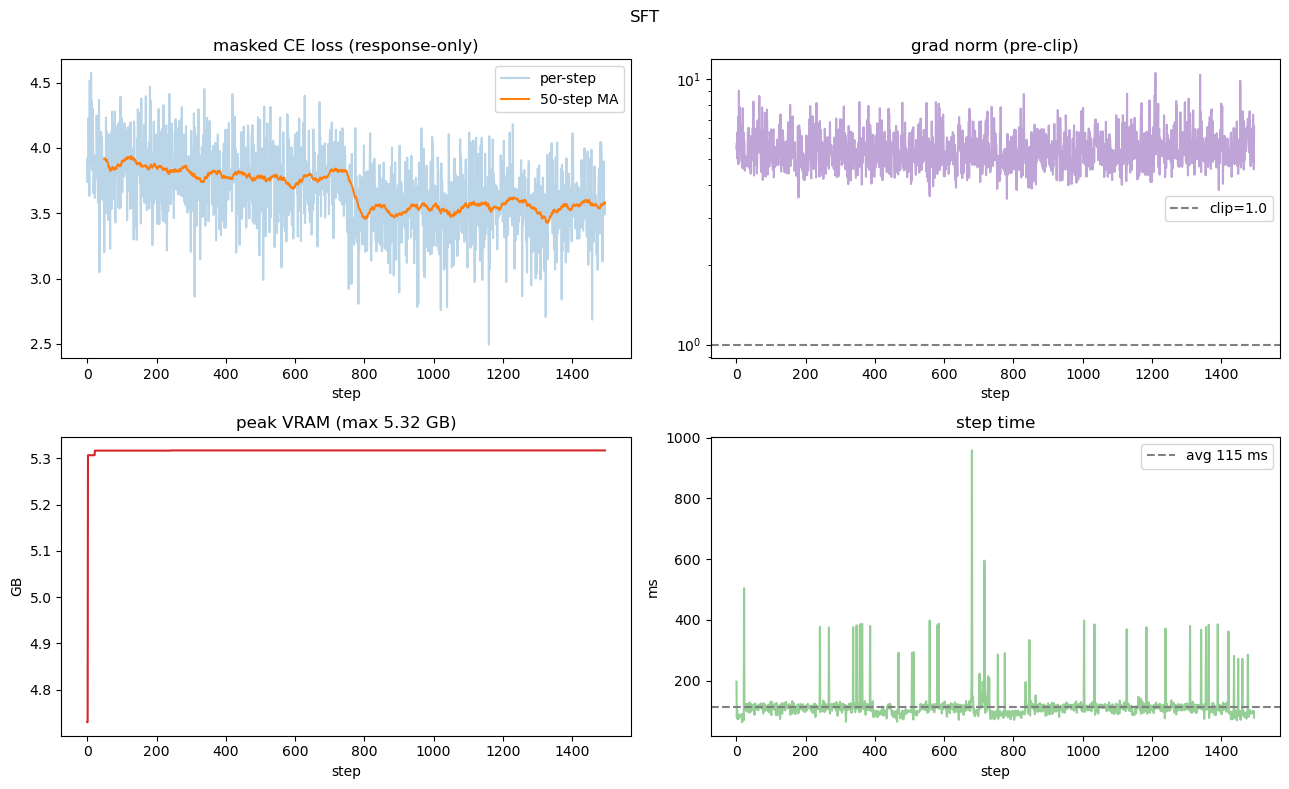

In [16]:
# SFT dashboard -- loss / grad-norm / VRAM / step-time on the real step axis
import matplotlib.pyplot as plt, numpy as np

h = hist
s = h["step"]
fig, ax = plt.subplots(2, 2, figsize=(13, 8))

ma = np.convolve(h["loss"], np.ones(50)/50, mode="valid")
ax[0, 0].plot(s, h["loss"], alpha=0.3, label="per-step")
ax[0, 0].plot(s[49:], ma, label="50-step MA")
ax[0, 0].set_title("masked CE loss (response-only)"); ax[0, 0].set_xlabel("step"); ax[0, 0].legend()

ax[0, 1].semilogy(s, h["grad_norm"], color="tab:purple", alpha=0.6)
ax[0, 1].axhline(1.0, ls="--", color="gray", label="clip=1.0")
ax[0, 1].set_title("grad norm (pre-clip)"); ax[0, 1].set_xlabel("step"); ax[0, 1].legend()

ax[1, 0].plot(s, h["vram_gb"], color="tab:red")
ax[1, 0].set_title(f"peak VRAM (max {max(h['vram_gb']):.2f} GB)"); ax[1, 0].set_xlabel("step"); ax[1, 0].set_ylabel("GB")

avg_ms = 1e3 * sum(h["batch_time"]) / len(h["batch_time"])
ax[1, 1].plot(s, [t*1e3 for t in h["batch_time"]], color="tab:green", alpha=0.5)
ax[1, 1].axhline(avg_ms, ls="--", color="gray", label=f"avg {avg_ms:.0f} ms")
ax[1, 1].set_title("step time"); ax[1, 1].set_xlabel("step"); ax[1, 1].set_ylabel("ms"); ax[1, 1].legend()

fig.suptitle("SFT"); plt.tight_layout(); plt.show()

In [17]:
# talk to the fine-tuned model -- it should now answer in-format and STOP
for q in ["What is the capital of France?",
          "Give me three tips for sleeping better.",
          "Explain what a transformer is in one sentence."]:
    print("Q:", q); print("A:", chat(model, q, max_new_tokens=150).strip()); print("-"*60)

Q: What is the capital of France?
A: The capital of France is Germany
------------------------------------------------------------
Q: Give me three tips for sleeping better.
A: 1. Go to a desk and sleep at least 20 minutes before bedtime, which is very important for your sleep.
2. As a group, stay hydrated and be able to keep your body good at night time.
3. Try to avoid bedtime and rest at least 20 minutes before bedtime.
4. Try to sleep at least 20 minutes before bedtime.

Dys and sleep at least 20 minutes before bedtime.

If you are not ready to go to bed at least 30 minutes before bedtime, you can also try to sleep for at least 30 minutes before bedtime.

In the future, be kind to sleep at least 15 minutes before bedtime.

For the most important
------------------------------------------------------------
Q: Explain what a transformer is in one sentence.
A: There are 3 types of inductive transistor. 
- AC
- AC
- AC
- DC
- AC
- AC
- AC
- AC
- AC
- AC
- AC
- AC
----------------------

## Done — you have a (tiny) chat model

`data/chat.pt` answers instructions in-template and stops at end-of-turn. The full chain works: **pretrain (3a) → SFT (3b) → chat**.

### Scale-up knobs (concepts unchanged)
- **Better data:** swap Dolly for `HuggingFaceTB/smol-smoltalk` (~460k, purpose-built for tiny models). Only `load_dataset(...)` and the field names in `format_example` change — smoltalk rows are `messages` lists (role/content), so map those into the same prompt/response split.
- **Bigger/longer base:** more pretraining in 3a is the highest-leverage improvement — SFT can't add knowledge the base never learned.
- **Multi-turn:** extend the template to multiple `### Instruction:/### Response:` turns, masking *every* user turn and training on *every* assistant turn (same `-100` rule, applied per turn).

### Where this sits vs the project's end goal
This is the English, single-task milestone. The handoff's larger goals — **multilingual** and **function-calling/agentic** — are the same machinery with different data: a multilingual pretraining slice (3a) and function-calling SFT data like Glaive/xLAM (3b), where the "response" is a tool call. Loss masking, templates, and the train loop you built here are exactly what those need.